In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,  mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import time

df = pd.read_csv('ToyotaCorolla.csv')

### 1. Загрузка данных
Загружаем датасет и проверяем его структуру, наличие пропусков и основные статистические показатели.

In [ ]:
print("Структура данных")
df.info()

print("\nСтатистика")
display(df.describe())

print("\nКоличество пропусков")
print(df.isnull().sum())

print("\nПервые 5 строк")
display(df.head())

Структура данных
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 n

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Количество пропусков
Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

Первые 5 строк


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


*   **Как вы предобрабатывали данные?** Удалены неинформативные столбцы, проверено отсутствие дубликатов и выполнено One-Hot кодирование категориальных признаков.
*   **Что вы поняли, проведя EDA?** Цена сильнее всего зависит от года выпуска и пробега; признак 'Cylinders' бесполезен, так как он константен.

In [ ]:
duplicate_count = df.duplicated().sum()
print(f'Найдено дубликатов: {duplicate_count}')
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Дубликаты удалены.')

# Удаление неинформативных признаков
cols_to_drop = ['Id', 'Model']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print(f'Удалены столбцы: {cols_to_drop}')

# Кодирование категориальных признаков
df = pd.get_dummies(df, columns=['Fuel_Type', 'Color'], drop_first=True)
print('Выполнено кодирование категориальных признаков')

# Вывод обновленного списка столбцов и первых строк
print('\nОбновленный список столбцов')
print(df.columns.tolist())

print('\nПервые 5 строк после предобработки')
display(df.head())

Найдено дубликатов: 0
Удалены столбцы: ['Id', 'Model']
Выполнено кодирование категориальных признаков

Обновленный список столбцов
['Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'Met_Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Color_Black', 'Color_Blue', 'Color_Green', 'Color_Grey', 'Color_Red', 'Color_Silver', 'Color_Violet', 'Color_White', 'Color_Yellow']

Первые 5 строк после предобработки


,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,...,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
0,13500,23,10,2002,46986,90,1,0,2000,3,...,False,False,True,False,False,False,False,False,False,False
1,13750,23,10,2002,72937,90,1,0,2000,3,...,False,False,False,False,False,False,True,False,False,False
2,13950,24,9,2002,41711,90,1,0,2000,3,...,False,False,True,False,False,False,False,False,False,False
3,14950,26,7,2002,48000,90,0,0,2000,3,...,False,True,False,False,False,False,False,False,False,False
4,13750,30,3,2002,38500,90,0,0,2000,3,...,False,True,False,False,False,False,False,False,False,False


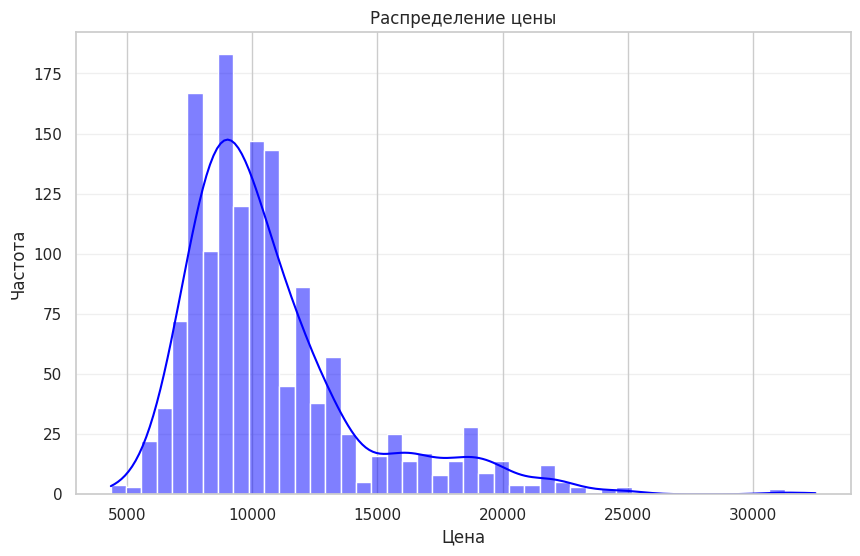

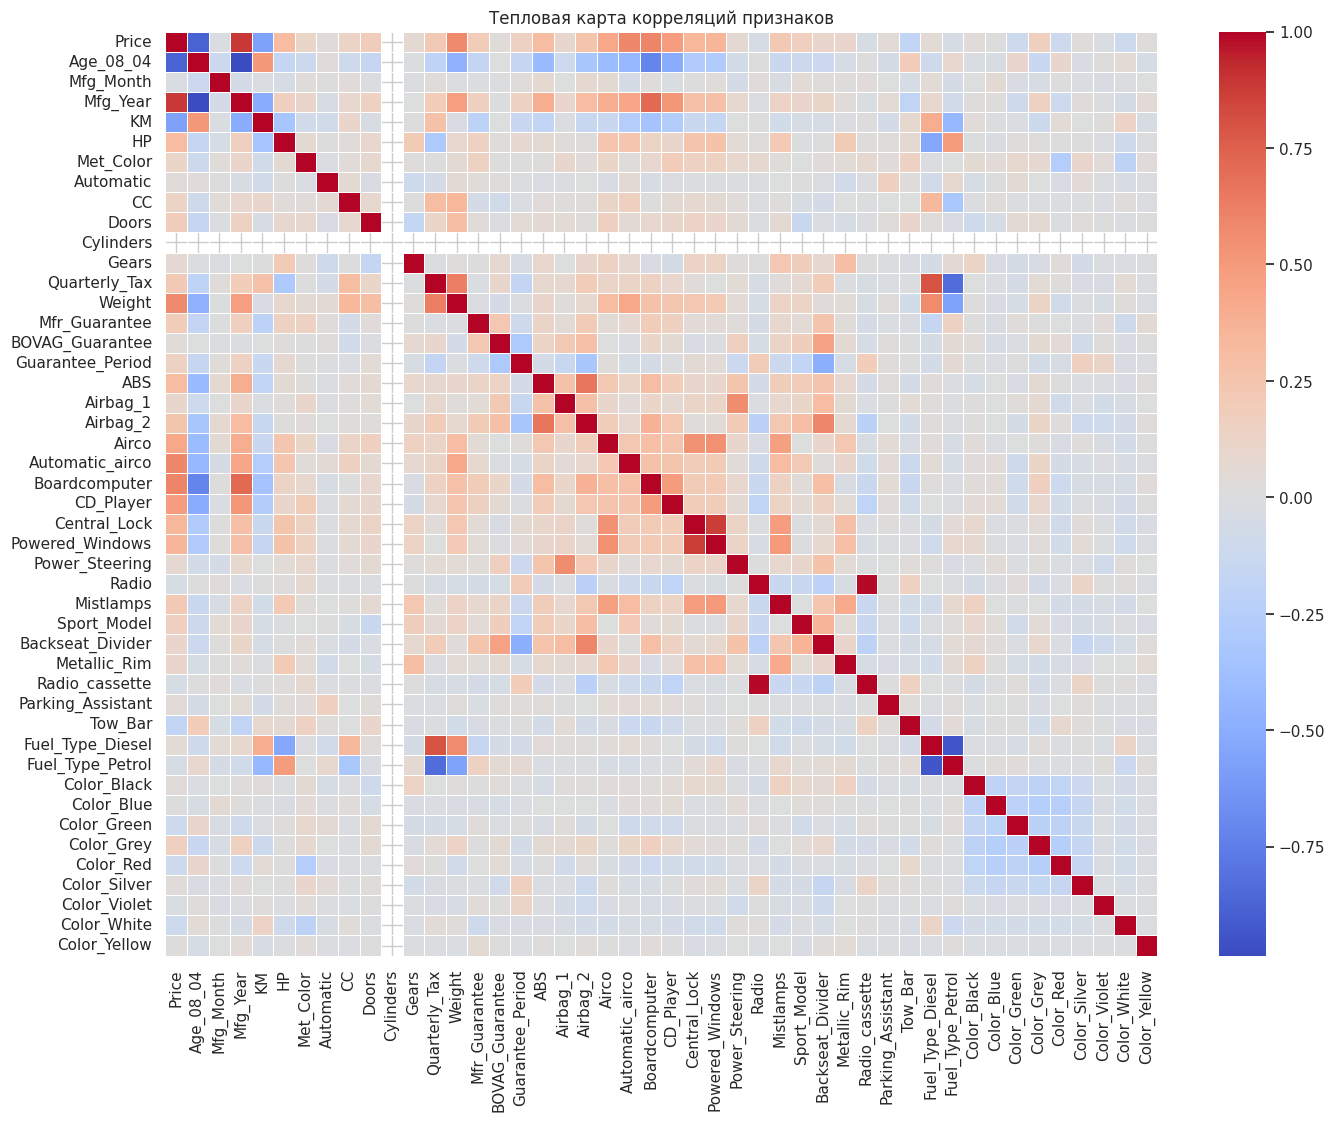

Топ-5 признаков с сильной положительной корреляцией
Mfg_Year           0.885159
Boardcomputer      0.601292
Automatic_airco    0.588262
Weight             0.581198
CD_Player          0.481374
Name: Price, dtype: float64

Топ-5 признаков с сильной отрицательной корреляцией
Color_Green   -0.104963
Tow_Bar       -0.172369
KM            -0.569960
Age_08_04     -0.876590
Cylinders           NaN
Name: Price, dtype: float64


In [ ]:

plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Распределение цены')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)
plt.show()

corr_matrix = df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций признаков')
plt.show()

price_correlations = corr_matrix['Price'].drop('Price').sort_values(ascending=False)
top_positive = price_correlations.head(5)
top_negative = price_correlations.tail(5)

print("Топ-5 признаков с сильной положительной корреляцией")
print(top_positive)

print("\nТоп-5 признаков с сильной отрицательной корреляцией")
print(top_negative)

In [ ]:
# Удаление константного признака 'Cylinders'
if 'Cylinders' in df.columns:
    df = df.drop(columns=['Cylinders'])
    print("Столбец 'Cylinders' удален (константное значение).")

# Удаление  Mfg_Year, он примерно противоположен Age_08_04
if 'Mfg_Year' in df.columns:
    df = df.drop(columns=['Mfg_Year'])
    print("Столбец 'Mfg_Year' удален (высокая корреляция с 'Age_08_04').")

print(f'\nНовая размерность датафрейма: {df.shape}')
print('\nОставшиеся ключевые признаки (первые 10):')
print(df.columns.tolist()[:10])

Столбец 'Cylinders' удален (константное значение).
Столбец 'Mfg_Year' удален (высокая корреляция с 'Age_08_04').

Новая размерность датафрейма: (1436, 44)

Оставшиеся ключевые признаки (первые 10):
['Price', 'Age_08_04', 'Mfg_Month', 'KM', 'HP', 'Met_Color', 'Automatic', 'CC', 'Doors', 'Gears']


In [ ]:
numerical_cols = ['Age_08_04', 'KM', 'HP', 'CC', 'Doors', 'Gears', 'Quarterly_Tax', 'Weight', 'Guarantee_Period']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Масштабирование")
print(f"Масштабированы: {numerical_cols}")

print("Статистика масштабированных параметров")
display(df[numerical_cols].describe().round(4))

print("\nПервые 5 строк")
display(df.head())


Масштабирование
Масштабированы: ['Age_08_04', 'KM', 'HP', 'CC', 'Doors', 'Gears', 'Quarterly_Tax', 'Weight', 'Guarantee_Period']
Статистика масштабированных параметров


,Age_08_04,KM,HP,CC,Doors,Gears,Quarterly_Tax,Weight,Guarantee_Period
count,1436.0000,1436.0000,1436.0000,1436.0000,1436.0000,1436.0000,1436.0000,1436.0000,1436.0000
mean,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000
std,1.0003,1.0003,1.0003,1.0003,1.0003,1.0003,1.0003,1.0003,1.0003
min,-2.9552,-1.8278,-2.1703,-0.6526,-2.1352,-10.7536,-1.6569,-1.3770,-0.2709
25%,-0.6425,-0.6810,-0.7680,-0.4169,-1.0851,-0.1404,-0.4408,-0.6168,-0.2709
50%,0.2718,-0.1372,0.5674,0.0546,-0.0351,-0.1404,-0.0516,-0.0467,-0.2709
75%,0.7558,0.4931,0.5674,0.0546,1.0149,-0.1404,-0.0516,0.2383,-0.2709
max,1.2936,4.6533,6.0429,33.9977,1.0149,5.1662,4.7642,10.3100,10.6926



Первые 5 строк


,Price,Age_08_04,Mfg_Month,KM,HP,Met_Color,Automatic,CC,Doors,Gears,...,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
0,13500,-1.771966,10,-0.574695,-0.768042,1,0,0.997419,-1.085139,-0.140425,...,False,False,True,False,False,False,False,False,False,False
1,13750,-1.771966,10,0.117454,-0.768042,1,0,0.997419,-1.085139,-0.140425,...,False,False,False,False,False,False,True,False,False,False
2,13950,-1.718184,9,-0.715386,-0.768042,1,0,0.997419,-1.085139,-0.140425,...,False,False,True,False,False,False,False,False,False,False
3,14950,-1.610620,7,-0.547650,-0.768042,0,0,0.997419,-1.085139,-0.140425,...,False,True,False,False,False,False,False,False,False,False
4,13750,-1.395491,3,-0.801028,-0.768042,0,0,0.997419,-1.085139,-0.140425,...,False,True,False,False,False,False,False,False,False,False


In [ ]:


X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('--- Результаты разделения данных ---')
print(f'Размер обучающей выборки (X_train): {X_train.shape}')
print(f'Размер тестовой выборки (X_test):   {X_test.shape}')
print(f'Размер целевой переменной (y_train): {y_train.shape}')
print(f'Размер целевой переменной (y_test):  {y_test.shape}')

print(f'\nДоля тестовой выборки: {len(X_test) / len(df):.1%}')

--- Результаты разделения данных ---
Размер обучающей выборки (X_train): (1148, 43)
Размер тестовой выборки (X_test):   (288, 43)
Размер целевой переменной (y_train): (1148,)
Размер целевой переменной (y_test):  (288,)

Доля тестовой выборки: 20.1%


*   **Как вы предобрабатывали данные?** Удалены неинформативные столбцы, проверено отсутствие дубликатов и выполнено One-Hot кодирование категориальных признаков.
*   **Что вы поняли, проведя EDA?** Цена сильнее всего зависит от года выпуска и пробега; признак 'Cylinders' бесполезен, так как он константен.
*   **Как вы работали с признаками?** Проведено масштабирование числовых данных через `StandardScaler` для корректной работы линейных моделей.
*   **Какие признаки вы удалили и почему?** Удалены `Id`, `Model` (уникальные строки), `Cylinders` (константа) и `Mfg_Year` (мультиколлинеарность с возрастом).
*   **Как именно вы разделили выборку?** Использовано случайное разделение `train_test_split` в пропорции 80% для обучения и 20% для теста.
*   **Для чего это нужно?** Чтобы оценить точность модели на новых данных и избежать заучивания тренировочного набора.

### 3. Обучение

In [ ]:
lr_model = LinearRegression()

start_time = time.time()
lr_model.fit(X_train, y_train)
end_time = time.time()

training_duration = end_time - start_time

print(f'Время обучения линейной регрессии: {training_duration:.6f} секунд')

model_stats = {'LinearRegression': {'training_time': training_duration}}

Время обучения линейной регрессии: 0.010046 секунд


In [ ]:
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge = Ridge()
ridge_cv = GridSearchCV(ridge, param_grid, cv=5)

start_ridge = time.time()
ridge_cv.fit(X_train, y_train)
end_ridge = time.time()

ridge_duration = end_ridge - start_ridge
model_stats['Ridge'] = {
    'best_alpha': ridge_cv.best_params_['alpha'],
    'training_time': ridge_duration,
    'best_model': ridge_cv.best_estimator_
}

lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(lasso, param_grid, cv=5)

start_lasso = time.time()
lasso_cv.fit(X_train, y_train)
end_lasso = time.time()

lasso_duration = end_lasso - start_lasso
model_stats['Lasso'] = {
    'best_alpha': lasso_cv.best_params_['alpha'],
    'training_time': lasso_duration,
    'best_model': lasso_cv.best_estimator_
}
print(f"Ridge: Best alpha={model_stats['Ridge']['best_alpha']}, Time={ridge_duration:.6f}s")
print(f"Lasso: Best alpha={model_stats['Lasso']['best_alpha']}, Time={lasso_duration:.6f}s")

Ridge: Best alpha=100.0, Time=0.326371s
Lasso: Best alpha=10.0, Time=0.656604s


Сравнение времени выполнения


,Duration (s)
LinearRegression,0.010046
Ridge,0.326371
Lasso,0.656604



Ridge (CV) медленнее базовой модели в 32.49 раз
Lasso (CV) медленнее базовой модели в 65.36 раз


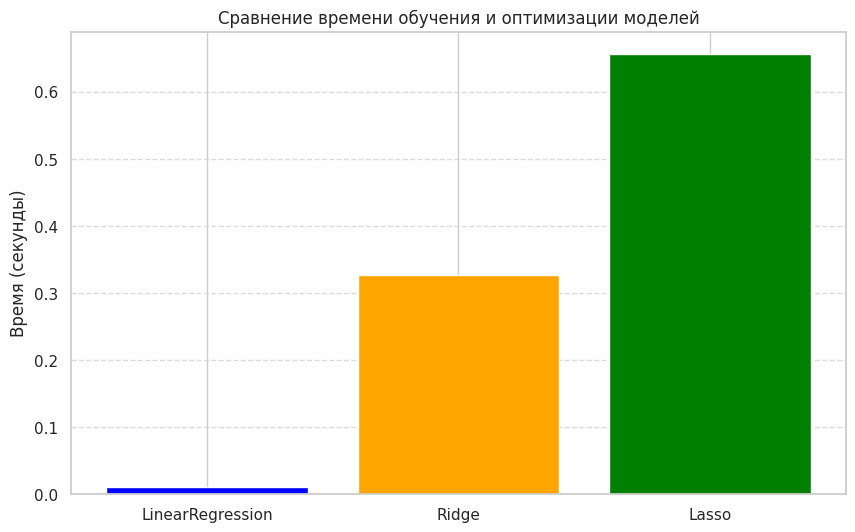

In [ ]:
times = {
    'LinearRegression': model_stats['LinearRegression']['training_time'],
    'Ridge': model_stats['Ridge']['training_time'],
    'Lasso': model_stats['Lasso']['training_time']
}

comparison_df = pd.DataFrame.from_dict(times, orient='index', columns=['Duration (s)'])

ridge_slowdown = times['Ridge'] / times['LinearRegression']
lasso_slowdown = times['Lasso'] / times['LinearRegression']

print("Сравнение времени выполнения")
display(comparison_df)
print(f"\nRidge (CV) медленнее базовой модели в {ridge_slowdown:.2f} раз")
print(f"Lasso (CV) медленнее базовой модели в {lasso_slowdown:.2f} раз")

plt.figure(figsize=(10, 6))
plt.bar(times.keys(), times.values(), color=['blue', 'orange', 'green'])
plt.title('Сравнение времени обучения и оптимизации моделей')
plt.ylabel('Время (секунды)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
models = {
    'LinearRegression': lr_model,
    'Ridge': model_stats['Ridge']['best_model'],
    'Lasso': model_stats['Lasso']['best_model']
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results).set_index('Model')

print("Сравнение точности моделей")
display(results_df.round(4))

model_stats['evaluation_results'] = results_df

Сравнение точности моделей


,MAE,RMSE,R2
Model,,,
LinearRegression,831.3959,1230.5210,0.8865
Ridge,836.2043,1229.3727,0.8867
Lasso,815.3833,1210.2471,0.8902


/tmp/ipykernel_246/1635682767.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[1], palette='viridis')
/tmp/ipykernel_246/1635682767.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='RMSE', data=results_df, ax=axes[2], palette='magma')


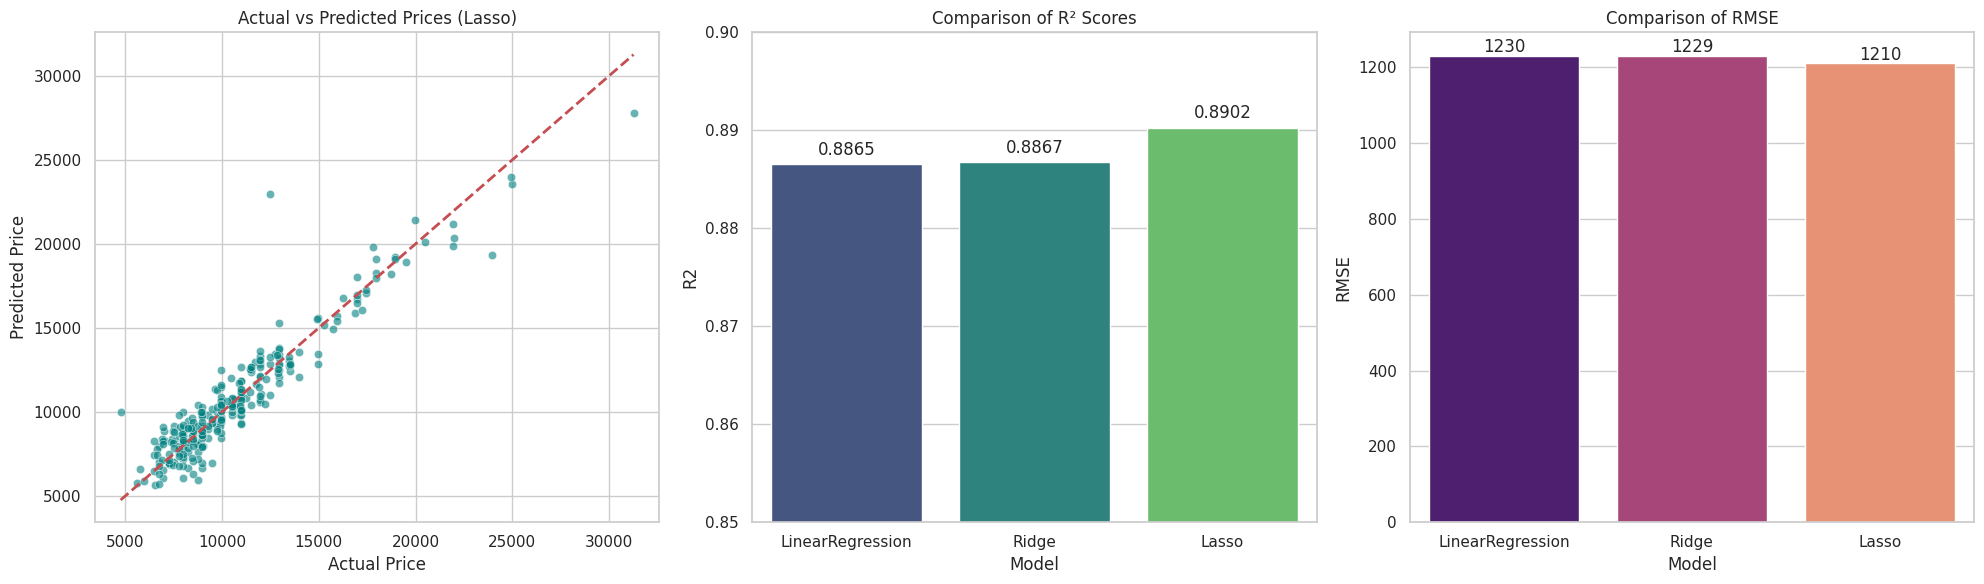

In [ ]:
best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x=y_test, y=y_pred_best, ax=axes[0], alpha=0.6, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted Prices ({best_model_name})')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[1], palette='viridis')
axes[1].set_title('Comparison of R² Scores')
axes[1].set_ylim(0.85, 0.90)
for i, v in enumerate(results_df['R2']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center')

sns.barplot(x=results_df.index, y='RMSE', data=results_df, ax=axes[2], palette='magma')
axes[2].set_title('Comparison of RMSE')
for i, v in enumerate(results_df['RMSE']):
    axes[2].text(i, v + 10, f'{int(v)}', ha='center')

plt.tight_layout()
plt.show()

*   **Как проходило обучение моделей?** Обучена обычная регрессия и оптимизированы Ridge/Lasso с помощью кросс-валидации через `GridSearchCV`.
*   **Сравнение скорости:** Обычная регрессия быстрее всех (прямой расчет), Lasso — медленнее из-за итеративного подбора параметров и 25 циклов обучения в GridSearchCV.
*   **Какие метрики вы использовали?** `MAE` (средняя ошибка в евро), `RMSE` (штраф за большие ошибки) и `R²` (общая точность модели).
*   **На какой части выборки считали метрики?** Основное сравнение моделей проводилось на тестовой выборке.
*   **Какая модель справилась лучше?** Модель **Lasso** показала лучший результат ($R^2 = 0.8902$).
*   **Насколько хорошие результаты?** Результаты отличные: модель объясняет 89% данных, средняя ошибка составляет около 815 евро.

In [ ]:
lasso_best = models['Lasso']

y_train_pred = lasso_best.predict(X_train)
y_test_pred = lasso_best.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

overfitting_check = pd.DataFrame({
    'Metric': ['R²', 'RMSE'],
    'Train Score': [r2_train, rmse_train],
    'Test Score': [r2_test, rmse_test],
    'Difference (%)': [abs(r2_train - r2_test) / r2_train * 100, abs(rmse_train - rmse_test) / rmse_train * 100]
})

print("Сравнение метрик на Train и Test (Lasso)")
display(overfitting_check.round(4))

diff_r2 = abs(r2_train - r2_test)
if diff_r2 < 0.05:
    print(f"\nРезультат: Разница R² составляет {diff_r2:.4f}.")
else:
    print(f"\nРезультат: Замечена существенная разница ({diff_r2:.4f}.")

Сравнение метрик на Train и Test (Lasso)


,Metric,Train Score,Test Score,Difference (%)
0,R²,0.9113,0.8902,2.3163
1,RMSE,1077.4673,1210.2471,12.3233



Результат: Разница R² составляет 0.0211.


*   **Чем докажете отсутствие переобучения?** Разрыв между точностью на обучении и тесте минимален (всего 2.1%), что подтверждает стабильность модели.